In [1]:
from pathlib import Path
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from tensorflow.keras import (
    layers,
    models,
    regularizers,
)

from tensorflow.keras.utils import (
    image_dataset_from_directory
)

# ====================================================
# 1. Global config
# ====================================================

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 123

root_dir = Path(
    "/data/users/zhouz6436/"
    "Pneumonia_image_classification/"
    "chest_xray_3class"
)

train_dir = root_dir / "train"
test_dir = root_dir / "test"

model_dir = root_dir.parent / "models"

AUTOTUNE = tf.data.AUTOTUNE

tf.keras.utils.set_random_seed(SEED)

I0000 00:00:1787320869.277552 1619273 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787320869.328256 1619273 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787320873.867313 1619273 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# ====================================================
# 2. Preprocessing
# Must match Model B exactly
# ====================================================

def preprocess(image, label):
    image = tf.cast(
        image,
        tf.float32
    )

    image = (
        tf.keras.applications
        .mobilenet_v2
        .preprocess_input(image)
    )

    return image, label


def prepare(
    dataset,
    shuffle=False
):
    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=1000,
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        preprocess,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


In [3]:
# ====================================================
# 3. Load three-class data
# ====================================================

train_full = image_dataset_from_directory(
    train_dir,
    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),
    shuffle=True,
    seed=SEED,
    batch_size=None,
)

test_raw = image_dataset_from_directory(
    test_dir,
    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),
    shuffle=False,
    batch_size=None,
)

class_names = train_full.class_names
test_class_names = test_raw.class_names
num_classes = len(class_names)

expected_classes = [
    "NORMAL",
    "bacteria",
    "virus"
]

print(
    "Training classes:",
    class_names
)

print(
    "Test classes:",
    test_class_names
)

print(
    "Number of classes:",
    num_classes
)

assert class_names == expected_classes, (
    f"Expected {expected_classes}, "
    f"found {class_names}"
)

assert test_class_names == class_names, (
    "Training and test class orders "
    "do not match"
)

Found 5232 files belonging to 3 classes.
Found 624 files belonging to 3 classes.
Training classes: ['NORMAL', 'bacteria', 'virus']
Test classes: ['NORMAL', 'bacteria', 'virus']
Number of classes: 3


E0000 00:00:1787320961.927467 1619273 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
# ====================================================
# 4. Same split and subsets as Model B
# ====================================================

total = (
    train_full
    .cardinality()
    .numpy()
)

val_size = int(
    0.10 * total
)

train_size = (
    total - val_size
)

train_raw = train_full.take(
    train_size
)

val_raw = train_full.skip(
    train_size
)

print(
    "Total images:",
    total
)

print(
    "Training images:",
    train_size
)

print(
    "Validation images:",
    val_size
)

total_train = (
    train_raw
    .cardinality()
    .numpy()
)


def make_subset_C(fraction):
    number_of_images = max(
        1,
        int(
            total_train
            * fraction
        )
    )

    subset_raw = train_raw.take(
        number_of_images
    )

    print(
        f"{int(fraction * 100)}% subset:",
        number_of_images,
        "images"
    )

    return prepare(
        subset_raw,
        shuffle=True
    )


train_10 = make_subset_C(0.10)
train_25 = make_subset_C(0.25)
train_50 = make_subset_C(0.50)

train_100 = prepare(
    train_raw,
    shuffle=True
)

val = prepare(
    val_raw,
    shuffle=False
)

test = prepare(
    test_raw,
    shuffle=False
)

for images, labels in test.take(1):
    print(
        "Test image shape:",
        images.shape
    )

    print(
        "Test label shape:",
        labels.shape
    )

Total images: 5232
Training images: 4709
Validation images: 523
10% subset: 470 images
25% subset: 1177 images
50% subset: 2354 images
Test image shape: (32, 224, 224, 3)
Test label shape: (32,)


In [5]:
# ====================================================
# 5. Improved Model C:
# load Model B, then partially fine-tune
# ====================================================

def make_backbone_C():
    return (
        tf.keras.applications
        .MobileNetV2(
            input_shape=(
                IMG_SIZE,
                IMG_SIZE,
                3
            ),
            include_top=False,
            weights="imagenet",
            pooling=None,
        )
    )


def make_model_C(
    model_B_weights_path,
    unfreeze_last_n=20,
    learning_rate=1e-5,
    l2_regularization=1e-4,
):
    backbone = make_backbone_C()

    # Initially reproduce the frozen Model B architecture
    backbone.trainable = False

    inputs = tf.keras.Input(
        shape=(
            IMG_SIZE,
            IMG_SIZE,
            3
        )
    )

    # training=False keeps Batch Normalization
    # in inference mode during fine-tuning
    x = backbone(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(
        x
    )

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=(
            regularizers.l2(
                l2_regularization
            )
        ),
    )(x)

    x = layers.Dropout(
        0.40
    )(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs
    )

    print(
        "Loading Model B weights:",
        model_B_weights_path
    )

    # Do not use skip_mismatch:
    # B and C weighted layers should match exactly.
    model.load_weights(
        model_B_weights_path
    )

    # Keep every layer frozen first
    for layer in backbone.layers:
        layer.trainable = False

    # Unfreeze only the final layers,
    # while keeping Batch Normalization frozen
    for layer in backbone.layers[
        -unfreeze_last_n:
    ]:
        if not isinstance(
            layer,
            layers.BatchNormalization
        ):
            layer.trainable = True

    model.compile(
        optimizer=(
            tf.keras.optimizers.Adam(
                learning_rate=(
                    learning_rate
                )
            )
        ),
        loss=(
            "sparse_categorical_"
            "crossentropy"
        ),
        metrics=["accuracy"],
    )

    trainable_backbone_layers = sum(
        layer.trainable
        for layer in backbone.layers
    )

    print(
        "Trainable backbone layers:",
        trainable_backbone_layers
    )

    return model


In [6]:
# ====================================================
# 6. Train Improved Model C
# ====================================================

EPOCHS = 20

c_subsets = OrderedDict({
    "10%": train_10,
    "25%": train_25,
    "50%": train_50,
    "100%": train_100,
})

B_weight_paths = {
    "10%": (
        model_dir
        / "model_B_3class_10pct.weights.h5"
    ),

    "25%": (
        model_dir
        / "model_B_3class_25pct.weights.h5"
    ),

    "50%": (
        model_dir
        / "model_B_3class_50pct.weights.h5"
    ),

    "100%": (
        model_dir
        / "model_B_3class_100pct.weights.h5"
    ),
}

fine_tuning_config = {
    "10%": {
        "unfreeze_last_n": 10,
        "learning_rate": 5e-6,
    },

    "25%": {
        "unfreeze_last_n": 15,
        "learning_rate": 5e-6,
    },

    "50%": {
        "unfreeze_last_n": 25,
        "learning_rate": 1e-5,
    },

    "100%": {
        "unfreeze_last_n": 35,
        "learning_rate": 1e-5,
    },
}

# Confirm all required B weights exist
for name, path in B_weight_paths.items():
    assert path.exists(), (
        f"Missing Model B weights "
        f"for {name}: {path}"
    )

histories_C = {}
tests_C = {}
models_C = OrderedDict()

for name, subset_dataset in (
    c_subsets.items()
):
    print(
        f"\n=== Improved Model C "
        f"three-class: {name} ==="
    )

    tf.keras.backend.clear_session()

    tf.keras.utils.set_random_seed(
        SEED
    )

    configuration = (
        fine_tuning_config[name]
    )

    model = make_model_C(
        model_B_weights_path=(
            B_weight_paths[name]
        ),
        unfreeze_last_n=(
            configuration[
                "unfreeze_last_n"
            ]
        ),
        learning_rate=(
            configuration[
                "learning_rate"
            ]
        ),
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.20,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),
    ]

    history = model.fit(
        subset_dataset,
        epochs=EPOCHS,
        validation_data=val,
        callbacks=callbacks,
        verbose=1
    )

    test_metrics = model.evaluate(
        test,
        return_dict=True,
        verbose=1
    )

    histories_C[name] = (
        history.history
    )

    tests_C[name] = test_metrics
    models_C[name] = model

    fraction_name = name.replace(
        "%",
        "pct"
    )

    C_weights_path = (
        model_dir
        / (
            "model_C_improved_3class_"
            f"{fraction_name}"
            ".weights.h5"
        )
    )

    model.save_weights(
        C_weights_path
    )

    print(
        "Saved Model C weights:",
        C_weights_path
    )

print(
    "\nImproved Model C "
    "three-class metrics:"
)

for name, metrics in tests_C.items():
    print(
        name,
        metrics
    )


=== Improved Model C three-class: 10% ===
Loading Model B weights: /data/users/zhouz6436/Pneumonia_image_classification/models/model_B_3class_10pct.weights.h5
Trainable backbone layers: 6
Epoch 1/20


/data/users/zhouz6436/miniconda3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 756ms/step - accuracy: 0.8064 - loss: 0.4935 - val_accuracy: 0.7801 - val_loss: 0.5392 - learning_rate: 5.0000e-06
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 469ms/step - accuracy: 0.7830 - loss: 0.5363 - val_accuracy: 0.7744 - val_loss: 0.5524 - learning_rate: 5.0000e-06
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 471ms/step - accuracy: 0.7851 - loss: 0.5308 - val_accuracy: 0.7763 - val_loss: 0.5353 - learning_rate: 5.0000e-06
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 462ms/step - accuracy: 0.7702 - loss: 0.5540 - val_accuracy: 0.7878 - val_loss: 0.5387 - learning_rate: 5.0000e-06
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.8000 - loss: 0.4913
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-07.
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 463ms/step - accuracy: 0.8000 - loss: 0.4913 - val_accuracy: 0.7820 - val_loss: 0.5732 - learning_rate: 5.0000e-06
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 464ms/step - accuracy: 0.7957 - loss: 

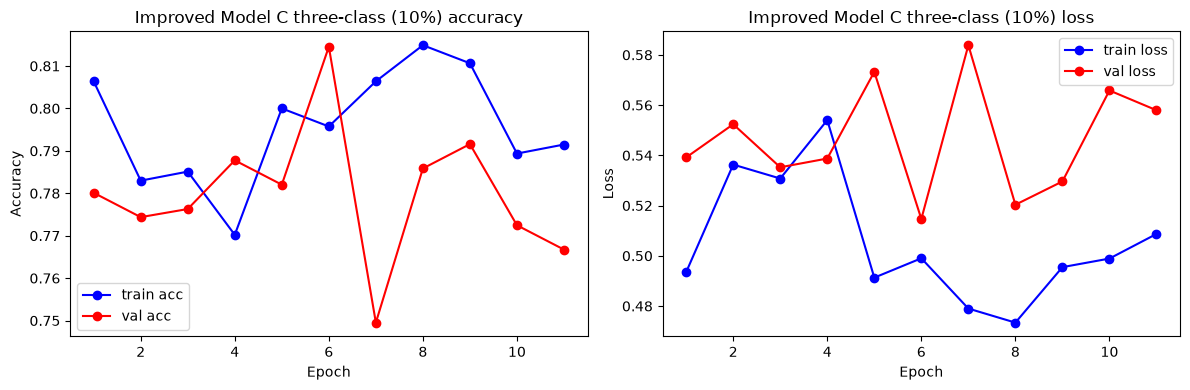

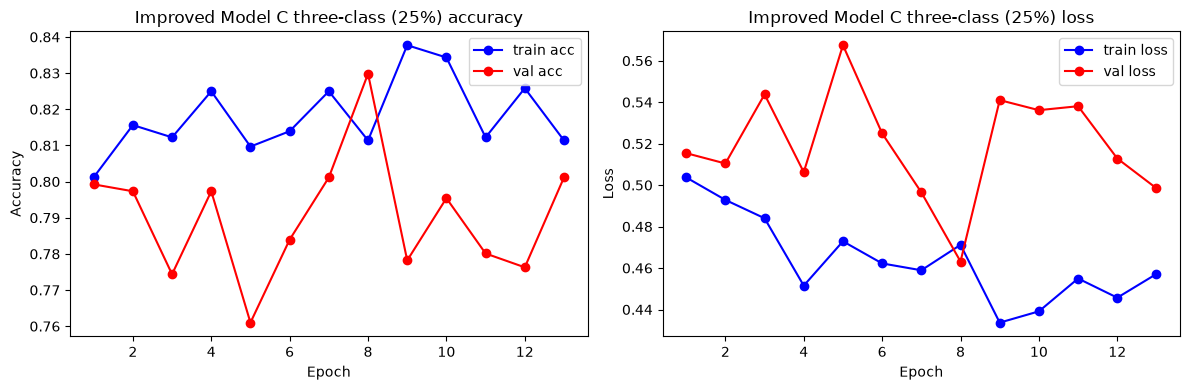

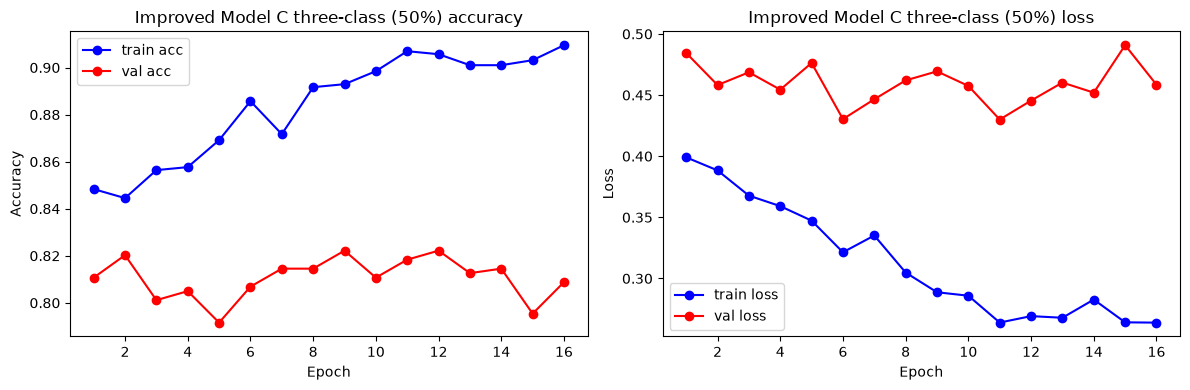

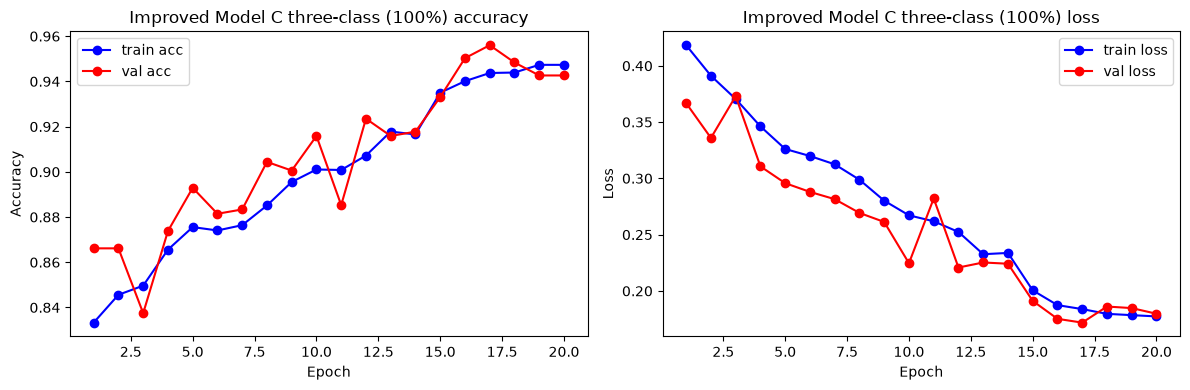

In [7]:
class HistoryWrapper:
    def __init__(self, hist_dict):
        self.history = hist_dict

def plot_history(history, title_prefix="Model"):
    acc      = history.history.get("accuracy", [])
    val_acc  = history.history.get("val_accuracy", [])
    loss     = history.history.get("loss", [])
    val_loss = history.history.get("val_loss", [])

    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    if len(acc) > 0:
        epochs_acc = range(1, len(acc) + 1)
        plt.plot(epochs_acc, acc, "bo-", label="train acc")
    if len(val_acc) > 0:
        epochs_val_acc = range(1, len(val_acc) + 1)
        plt.plot(epochs_val_acc, val_acc, "ro-", label="val acc")
    plt.title(f"{title_prefix} accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    if len(loss) > 0:
        epochs_loss = range(1, len(loss) + 1)
        plt.plot(epochs_loss, loss, "bo-", label="train loss")
    if len(val_loss) > 0:
        epochs_val_loss = range(1, len(val_loss) + 1)
        plt.plot(epochs_val_loss, val_loss, "ro-", label="val loss")
    plt.title(f"{title_prefix} loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()
    
for fraction, history_dict in (
    histories_C.items()
):
    plot_history(
        HistoryWrapper(
            history_dict
        ),
        title_prefix=(
            "Improved Model C "
            "three-class "
            f"({fraction})"
        )
    )

In [8]:
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

# ====================================================
# 8. Improved Model C evaluation
# ====================================================

y_true = np.concatenate([
    labels.numpy().ravel()
    for _, labels in test_raw
])

label_indices = list(
    range(num_classes)
)

print("Class mapping:")

for index, class_name in enumerate(
    class_names
):
    print(
        index,
        "=",
        class_name
    )


for name, model in models_C.items():
    print(
        f"\n=== Improved Model C "
        f"evaluation: {name} ==="
    )

    probabilities = model.predict(
        test,
        verbose=1
    )

    y_pred = np.argmax(
        probabilities,
        axis=1
    )

    print(
        "Predicted-label counts:"
    )

    for index, class_name in enumerate(
        class_names
    ):
        count = int(
            np.sum(
                y_pred == index
            )
        )

        print(
            class_name,
            ":",
            count
        )

    print(
        "\nClassification report:"
    )

    print(
        classification_report(
            y_true,
            y_pred,
            labels=label_indices,
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=label_indices
    )

    print("Confusion matrix:")
    print(matrix)

    balanced_accuracy = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    print(
        "Balanced accuracy:",
        round(
            balanced_accuracy,
            4
        )
    )

    print(
        "Macro F1:",
        round(
            macro_f1,
            4
        )
    )


Class mapping:
0 = NORMAL
1 = bacteria
2 = virus

=== Improved Model C evaluation: 10% ===
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step
Predicted-label counts:
NORMAL : 165
bacteria : 306
virus : 153

Classification report:
              precision    recall  f1-score   support

      NORMAL     0.9818    0.6923    0.8120       234
    bacteria     0.7712    0.9752    0.8613       242
       virus     0.6732    0.6959    0.6844       148

    accuracy                         0.8029       624
   macro avg     0.8088    0.7878    0.7859       624
weighted avg     0.8270    0.8029    0.8009       624

Confusion matrix:
[[162  25  47]
 [  3 236   3]
 [  0  45 103]]
Balanced accuracy: 0.7878
Macro F1: 0.7859

=== Improved Model C evaluation: 25% ===
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step
Predicted-label counts:
NORMAL : 174
bacteria : 298
virus : 152

Classification report:
              precision    recall  f1-score   support

      NORMAL     0.9770    0.7265    0.8333       234
    bacteria